CALIMLIM, Leander Keith A.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from google.colab import files
uploaded = files.upload()


Saving Titanic-Dataset.csv to Titanic-Dataset (1).csv


**ORIGINAL DATASET**

In [ ]:
df = pd.read_csv('Titanic-Dataset.csv')

print("---------------MISSING VALUES-----------------")
print(df.isnull().sum())

print("\n-----------------DATASET PREVIEW---------------")
print(df.head())

df.fillna({
    'Age': df['Age'].median(),
    'Embarked': df['Embarked'].mode()[0],
}, inplace=True)

df = df.drop(['Cabin'], axis=1)

---------------MISSING VALUES-----------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

-----------------DATASET PREVIEW---------------
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male 

**UPDATED DATASET**

In [ ]:
print("---------------MISSING VALUES-----------------")
print(df.isnull().sum())

print("\n-----------------DATASET PREVIEW---------------")
print(df.head())

---------------MISSING VALUES-----------------
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

-----------------DATASET PREVIEW---------------
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Tick

**DATA TRANSFORMATION**

In [ ]:
minMaxScaler = MinMaxScaler()
df['Normalized (Min-max)'] = minMaxScaler.fit_transform(df[['Age']])

zScoreScaler = StandardScaler()
df['Standardized (z-score)'] = zScoreScaler.fit_transform(df[['Age']])

print("--------------------COMPARISON------------------")
print(df[['Age', 'Normalized (Min-max)', 'Standardized (z-score)']].head(10))


--------------------COMPARISON------------------
    Age  Normalized (Min-max)  Standardized (z-score)
0  22.0              0.271174               -0.565736
1  38.0              0.472229                0.663861
2  26.0              0.321438               -0.258337
3  35.0              0.434531                0.433312
4  35.0              0.434531                0.433312
5  28.0              0.346569               -0.104637
6  54.0              0.673285                1.893459
7   2.0              0.019854               -2.102733
8  27.0              0.334004               -0.181487
9  14.0              0.170646               -1.180535


**Inspection of Raw Column SibSp and Parch**

In [ ]:
print(df[['SibSp', 'Parch']].dtypes)

SibSp    int64
Parch    int64
dtype: object


**Feature Engineering of FamilySize**

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.rename(columns={
    'SibSp': 'No. Of Sibling or Spouse',
    'Parch': 'No. of Parent or Children'
}, inplace=True)
print(df[['No. Of Sibling or Spouse','No. of Parent or Children','FamilySize']].head(10))

   No. Of Sibling or Spouse  No. of Parent or Children  FamilySize
0                         1                          0           2
1                         1                          0           2
2                         0                          0           1
3                         1                          0           2
4                         0                          0           1
5                         0                          0           1
6                         0                          0           1
7                         3                          1           5
8                         0                          2           3
9                         1                          0           2


**Interpretation**

*   A value of 1 means the passenger is traveling alone.
*   A value greater than 1 means the passenger is traveling with one or more family members.
*   Larger family groups (4+) may show different survival behavior.









**Frequency Table for FamilySize**

In [ ]:
family_freq = df['FamilySize'].value_counts().sort_index()
print(family_freq)

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


**Histogram of Family Size**

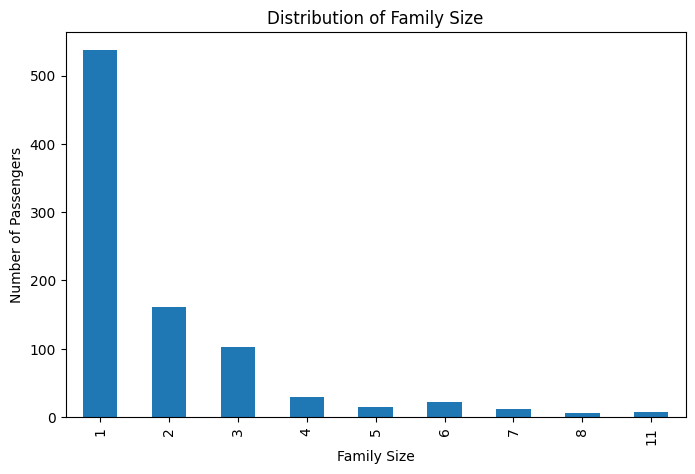

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
family_freq.plot(kind='bar')
plt.xlabel('Family Size')
plt.ylabel('Number of Passengers')
plt.title('Distribution of Family Size')
plt.show()

**INTERPRETATION OF Family SIze Histogram**

Most of the passengers have no family members while there are some passengers that have moderate to large family sizes.

**Comparison of Survived vs FamilySize**

In [ ]:
survival_by_family = df.groupby('FamilySize')['Survived'].mean()
print(survival_by_family)

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


**Histogram of Survival Rate by Family Size**

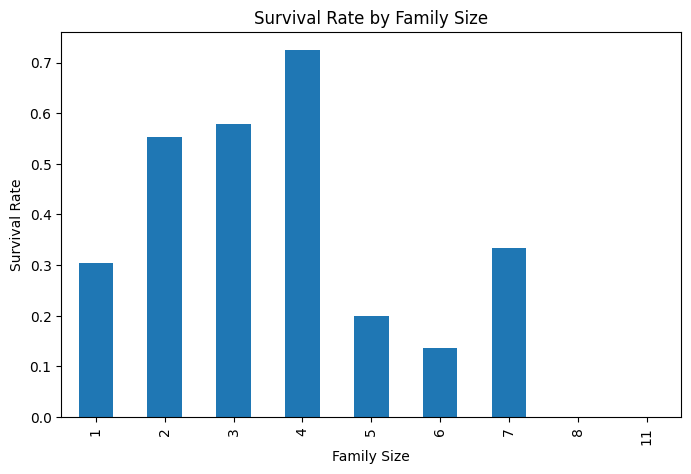

In [ ]:
plt.figure(figsize=(8,5))
survival_by_family.plot(kind='bar')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Family Size')
plt.show()

**Interpretation on FamilySize vs Survival Rate**

* Passengers traveling alone (FamilySize = 1) had lower survival rates.

* Passengers with small families (2–4 members) showed higher chances of survival.

* Very large families had reduced survival, possibly due to difficulty staying together during evacuation.

* This suggests that moderate family support may have improved survival odds.

**IsAlone Feature Enginnering**

In [ ]:
df['IsAlone'] = (df['FamilySize'] == 1)
print(df[['FamilySize','IsAlone']].head(10))

   FamilySize  IsAlone
0           2    False
1           2    False
2           1     True
3           2    False
4           1     True
5           1     True
6           1     True
7           5    False
8           3    False
9           2    False


**PART 2: ENCODING SEX FEATURE**

In [ ]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

**Binary Label Encoding**

In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [ ]:
df['Sex'].unique()

array([0, 1])